# Stage 3 — Mars interactive network exploration

_Pipeline stage 3 of `docs/PIPELINE_DESIGN.md`. Uses the canonical `channel_heads` package + on-disk artifacts; heavy rebuilds run via the `channel-heads` CLI (see each stage's command)._

## Mars valley networks — the target landscape

Mars networks are **already-mapped valley-network polylines** (391 networks), not
DEM-derived. Their geometry reflects whatever fluvial signal survived ~3.5 Gyr of
degradation. The Earth->Mars transfer is only valid if Earth training networks have
comparable **drainage density**, so we characterize the Mars Dd distribution here —
the target Stage 4 calibrates Earth against.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import channel_heads as ch
from channel_heads.io.paths import PROJECT_ROOT, RESULTS_DIR, EXAMPLE_DEMS
ROOT     = PROJECT_ROOT
MODELS   = ROOT / 'models'
MARS_OUT = ROOT / 'data/Mars/model_outputs'
MARS_IN  = ROOT / 'data/Mars/model_inputs'
REGIMES_ = ['regA', 'regB', 'regC']
# Frozen model features (5 dimensionless) + operating thresholds (Stage 9).
MODEL_FEATURES = ['orientation_diff_deg','headhead_dist_norm','apex_angle_deg',
                  'strahler_order_diff','proximity_profile_norm']
OP_THR = {'regA': 0.756326, 'regB': 0.779264, 'regC': 0.759369}
print('channel_heads', ch.__version__, '| root', ROOT)


channel_heads 0.1.0 | root /Users/guypi/Projects/channel-heads


In [2]:
from channel_heads.io.paths import MARS_DIR
from channel_heads.dd_calibration import mars_network_table
gpkg = MARS_DIR / 'topology' / 'mars_vn_topology_model_ready.gpkg'
net = mars_network_table(gpkg if gpkg.exists() else None)
print(f'Mars networks: {len(net)}')
net[['length_km','hull_area_km2','dd_hull_km_km2']].describe().round(2)

Mars networks: 391


,length_km,hull_area_km2,dd_hull_km_km2
count,391.00,391.00,391.00
mean,171.14,1531.35,0.24
std,172.78,7008.23,0.12
min,28.44,50.40,0.02
25%,80.76,280.48,0.16
50%,122.41,567.49,0.22
75%,213.14,1239.09,0.30
max,2313.50,133510.85,0.73


### Distribution of martian network drainage density

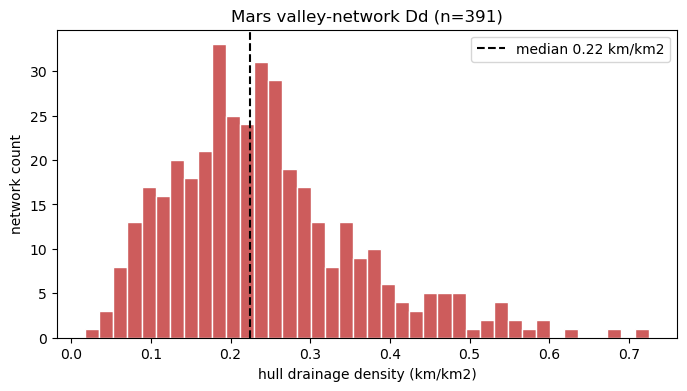

Mars median Dd = 0.224 km/km2 (Earth regimes bracket this)


In [3]:
dd = net['dd_hull_km_km2'].dropna()
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dd, bins=40, color='indianred', edgecolor='white')
ax.axvline(dd.median(), color='k', ls='--', label=f'median {dd.median():.2f} km/km2')
ax.set_xlabel('hull drainage density (km/km2)'); ax.set_ylabel('network count')
ax.set_title('Mars valley-network Dd (n=%d)' % len(dd)); ax.legend(); plt.show()
print('Mars median Dd = %.3f km/km2 (Earth regimes bracket this)' % dd.median())

Deep dive: `notebooks/mars/00_mars_network_explorer.ipynb` (maps on MOLA hillshade).